In [8]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from types import SimpleNamespace

plt.rcParams.update({
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.family": "Time New Roman",
    "font.size": 12,
    "xtick.direction": "in",
    "ytick.direction": "in",
})


# Adaptive time stepping test

In [9]:
eps = 3
t_ini = 0
data_path = Path(f"data/03_mrSAV_varstep_exp_data_{eps}_{t_ini}.npz")

## Load precomputed data

The simulation part has been moved to `03_run_mrsav_varstep_exp.py`.
Run `python 03_run_mrsav_varstep_exp.py --force` to regenerate `data/03_mrSAV_varstep_exp_data.npz`.


In [10]:
def tol_key(rtol, rtol_q):
    return (float(f"{rtol:.12g}"), float(f"{rtol_q:.12g}"))


def _scalar_string(value):
    return str(np.asarray(value).item())


def load_varstep_results(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"Missing data file: {path}. Run `python 03_run_mrsav_varstep_exp.py --force` first."
        )

    data = np.load(path, allow_pickle=False)

    params = {
        "nu": float(data["nu"]),
        "m": int(data["m"]),
        "eps": float(data["eps"]),
        "t_ini": float(data["t_ini"]),
        "gam": float(data["gam"]),
        "s_domain": tuple(data["s_domain"].tolist()),
        "discrete_num": data["discrete_num"].astype(int).tolist(),
        "t_period": tuple(data["t_period"].tolist()),
        "ref_tau": float(data["ref_tau"]),
    }

    tol_grid_list = list(zip(data["tol_grid_rtol"].tolist(), data["tol_grid_rtol_q"].tolist()))
    tol_perturb_list = list(zip(data["tol_perturb_rtol"].tolist(), data["tol_perturb_rtol_q"].tolist()))

    all_adaptive_results = []
    for i in range(int(data["adaptive_count"])):
        all_adaptive_results.append({
            "rtol": float(data[f"adaptive_{i}_rtol"]),
            "rtol_q": float(data[f"adaptive_{i}_rtol_q"]),
            "cpu_time": data[f"adaptive_{i}_cpu_time"],
            "step_count": int(data[f"adaptive_{i}_step_count"]),
            "tn": data[f"adaptive_{i}_tn"],
            "tau": data[f"adaptive_{i}_tau"],
            "ref_err": data[f"adaptive_{i}_ref_err"],
            "rel_err": data[f"adaptive_{i}_rel_err"],
            "ref_err_p": data[f"adaptive_{i}_ref_err_p"],
        })

    adaptive_result_by_tol = {
        tol_key(res["rtol"], res["rtol_q"]): res
        for res in all_adaptive_results
    }
    tol_grid_results = [adaptive_result_by_tol[tol_key(*tol)] for tol in tol_grid_list]
    tol_perturb_results = [adaptive_result_by_tol[tol_key(*tol)] for tol in tol_perturb_list]

    fixed_results = []
    for i in range(int(data["fixed_count"])):
        fixed_results.append({
            "key": _scalar_string(data[f"fixed_{i}_key"]),
            "tau": float(data[f"fixed_{i}_tau"]),
            "color": _scalar_string(data[f"fixed_{i}_color"]),
            "marker": _scalar_string(data[f"fixed_{i}_marker"]),
            "linestyle": _scalar_string(data[f"fixed_{i}_linestyle"]),
            "markevery": int(data[f"fixed_{i}_markevery"]),
            "tn": data[f"fixed_{i}_tn"],
            "tau_values": data[f"fixed_{i}_tau_values"],
            "q": data[f"fixed_{i}_q"],
            "cpu_time": data[f"fixed_{i}_cpu_time"],
            "ref_error": data[f"fixed_{i}_ref_error"],
        })

    ref_solution = {"tn": data["ref_tn"]}

    return {
        **params,
        "tol_grid_list": tol_grid_list,
        "tol_perturb_list": tol_perturb_list,
        "all_adaptive_results": all_adaptive_results,
        "tol_grid_results": tol_grid_results,
        "tol_perturb_results": tol_perturb_results,
        "fixed_results": fixed_results,
        "ref_solution": ref_solution,
    }


loaded = load_varstep_results(data_path)
globals().update(loaded)

# assert len(tol_grid_results) == 9
# assert len(tol_perturb_results) == 9

# Backward-compatible aliases for any later ad-hoc cells.
solver_2h_fix_1 = SimpleNamespace(**fixed_results[0])
solver_2h_fix_2 = SimpleNamespace(**fixed_results[1])
solver_2h_fix_3 = SimpleNamespace(**fixed_results[2])
solver_2h_fix_5 = SimpleNamespace(**ref_solution)
ref_error_fix = fixed_results[0]["ref_error"]
ref_error_fix_2 = fixed_results[1]["ref_error"]
ref_error_fix_3 = fixed_results[2]["ref_error"]

print(f"Loaded data from {data_path}")
print(f"adaptive runs: {len(all_adaptive_results)}, fixed runs: {len(fixed_results)}")


Loaded data from data/03_mrSAV_varstep_exp_data_3_0.npz
adaptive runs: 17, fixed runs: 4


In [11]:
adaptive_styles = [
    {"color": "C0", "marker": "o", "linestyle": "-",  "offset": 0,   "zorder": 3},
    {"color": "C4", "marker": "^", "linestyle": "--", "offset": 80,  "zorder": 6},
    {"color": "C5", "marker": "v", "linestyle": "-.", "offset": 40,  "zorder": 5},
    {"color": "C6", "marker": "P", "linestyle": ":",  "offset": 120, "zorder": 4},
    {"color": "C7", "marker": "X", "linestyle": "-",  "offset": 160, "zorder": 7},
    {"color": "C8", "marker": "D", "linestyle": "--", "offset": 200, "zorder": 8},
    {"color": "C2", "marker": "h", "linestyle": "-.", "offset": 240, "zorder": 9},
    {"color": "black", "marker": "<", "linestyle": ":", "offset": 280, "zorder": 10},
    {"color": "goldenrod", "marker": ">", "linestyle": "-",  "offset": 320, "zorder": 11},
]

def adaptive_label(res):
    return rf"Ada. $({res['rtol']:.1e}, {res['rtol_q']:.1e})$"

def validate_unique_markers(adaptive_results):
    if len(adaptive_results) > len(adaptive_styles):
        raise ValueError(
            f"Need {len(adaptive_results)} adaptive markers, but only "
            f"{len(adaptive_styles)} adaptive styles are defined."
        )
    adaptive_markers = [style["marker"] for style in adaptive_styles[:len(adaptive_results)]]
    fixed_markers = [res["marker"] for res in fixed_results]
    all_markers = adaptive_markers + fixed_markers
    if len(all_markers) != len(set(all_markers)):
        duplicates = sorted({marker for marker in all_markers if all_markers.count(marker) > 1})
        raise ValueError(f"Repeated markers found: {duplicates}")


def plot_adaptive(ax, y, adaptive_results, markevery=300, label=False):
    for i, res in enumerate(adaptive_results):
        style = adaptive_styles[i]
        mark = (style["offset"], markevery)
        ax.plot(res["tn"][2:], y(res)[2:], color=style["color"], marker=style["marker"],
                linestyle=style["linestyle"], linewidth=1, markersize=4,
                markeredgewidth=0, markevery=mark, zorder=style["zorder"],
                label=adaptive_label(res) if label else None)


def zero_at_time(t, y, t0=0.0):
    i0 = int(np.argmin(np.abs(t - t0)))
    return y - y[i0]


def plot_comparison(adaptive_results, output_path, legend_ncol=4):
    validate_unique_markers(adaptive_results)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    fig = plt.figure(figsize=(17, 15))

    ax1 = plt.subplot2grid((6, 6), (0, 0), colspan=2, rowspan=2)
    plot_adaptive(ax1, lambda res: res["tau"], markevery=200, label=True, adaptive_results=adaptive_results)
    for res in fixed_results:
        ax1.plot(np.linspace(t_period[0], t_period[1], 61), np.ones(61) * res['tau'],
                 color=res['color'], marker=res['marker'], markeredgewidth=0, markersize=5,
                 linewidth=1, linestyle=res['linestyle'], label=rf"$\tau = {res['tau']:.3g}$")
    ax1.hlines(1e-2, 0, 60, colors='k', linestyles='dashed', alpha=0.5, linewidth=1)
    ax1.hlines(1e-5, 0, 60, colors='k', linestyles='dashed', alpha=0.5, linewidth=1)
    ax1.set_yscale("log")
    ax1.set_xlim(*t_period)
    # ax1.set_xlim(0,.1)
    ax1.set_xlabel(r"$t$", fontsize=15)
    ax1.set_ylabel(r"Step sizes", fontsize=12)
    ax1.grid(alpha=0.5, linestyle='dashed', linewidth=0.5)

    ax6 = plt.subplot2grid((6, 6), (0, 2), colspan=2, rowspan=2)
    plot_adaptive(ax6, lambda res: zero_at_time(res["tn"], np.arange(len(res["tn"]))), adaptive_results=adaptive_results)
    for res in fixed_results:
        step_count = zero_at_time(res["tn"], np.arange(len(res["tn"])))
        ax6.plot(res['tn'], step_count, linewidth=1, color=res['color'],
                 marker=res['marker'], markeredgewidth=0, markersize=5,
                 markevery=res['markevery'], linestyle=res['linestyle'])
    ax6.set_xlim(*t_period)
    ax6.set_ylim(bottom=0)
    ax6.set_xlabel(r"$t$", fontsize=15)
    ax6.set_ylabel(r"Step count", fontsize=12)
    ax6.grid(alpha=0.5, linestyle='dashed', linewidth=0.5)

    ax2 = plt.subplot2grid((6, 6), (0, 4), colspan=2, rowspan=2)
    plot_adaptive(ax2, lambda res: zero_at_time(res["tn"], res["cpu_time"]), adaptive_results=adaptive_results)
    for res in fixed_results:
        cpu_time = zero_at_time(res["tn"], res["cpu_time"])
        ax2.plot(res['tn'], cpu_time, color=res['color'], marker=res['marker'],
                 markeredgewidth=0, markersize=5, markevery=res['markevery'], linewidth=1)
    ax2.set_xlim(*t_period)
    ax2.set_ylim(bottom=0)
    ax2.set_xlabel(r"$t$", fontsize=15)
    ax2.set_ylabel(r"CPU time (s)", fontsize=12)
    ax2.grid(alpha=0.5, linestyle='dashed', linewidth=0.5)

    ax3 = plt.subplot2grid((6, 6), (2, 0), colspan=2, rowspan=2)
    plot_adaptive(ax3, lambda res: res["ref_err_p"], markevery=200, adaptive_results=adaptive_results)
    for res in fixed_results:
        ax3.plot(res['tn'], np.abs(res['q'] - 1), marker=res['marker'], markeredgewidth=0,
                 markersize=5, markevery=res['markevery'], linewidth=1, color=res['color'])
    ax3.hlines(1e-4, 0, 60, colors='k', linestyles='dashed', alpha=0.5, linewidth=1)
    ax3.set_yscale("log")
    ax3.set_xlim(*t_period)
    ax3.set_ylim(1e-9, 1e1)
    ax3.set_xlabel(r"$t$", fontsize=15)
    ax3.set_ylabel(r"$| r |$", fontsize=12)
    ax3.grid(alpha=0.5, linestyle='dashed', linewidth=0.5)

    ax4 = plt.subplot2grid((6, 6), (2, 2), colspan=2, rowspan=2)
    plot_adaptive(ax4, lambda res: res["rel_err"], adaptive_results=adaptive_results)
    ax4.hlines(1e-4, 0, 60, colors='k', linestyles='dashed', alpha=0.5, linewidth=1)
    ax4.set_yscale("log")
    ax4.set_xlim(*t_period)
    ax4.set_ylim(1e-9, 1e-2)
    ax4.set_yticks([1e-8, 1e-6, 1e-4, 1e-2])
    ax4.set_xlabel(r"$t$", fontsize=15)
    ax4.set_ylabel(r"Relative $L^2$ error of Vorticity", fontsize=12)
    ax4.grid(alpha=0.5, linestyle='dashed', linewidth=0.5)

    ax5 = plt.subplot2grid((6, 6), (2, 4), colspan=2, rowspan=2)
    plot_adaptive(ax5, lambda res: res["ref_err"], adaptive_results=adaptive_results)
    for res in fixed_results:
        ax5.plot(res["tn"][1:], res['ref_error'][1:], linewidth=1, color=res['color'], marker=res['marker'],
                 markeredgewidth=0, markersize=5, markevery=500, linestyle=res['linestyle'])
    ax5.hlines(1e-4, 0, 60, colors='k', linestyles='dashed', alpha=0.5, linewidth=1)
    ax5.set_yscale("log")
    ax5.set_xlim(*t_period)
    ax5.set_ylim(1e-6, 1e1)
    ax5.set_yticks([1e-6, 1e-4, 1e-2, 1e0])
    ax5.set_xlabel(r"$t$", fontsize=15)
    ax5.set_ylabel(r"Reference relative $L^2$ error of Vorticity", fontsize=12)
    ax5.grid(alpha=0.5, linestyle='dashed', linewidth=0.5)

    # 子图标签：按布局顺序 (a)-(f)
    for label, ax_sub in zip(['(a)', '(b)', '(c)', '(d)', '(e)', '(f)'], [ax1, ax6, ax2, ax3, ax4, ax5]):
        ax_sub.text(x=0.5, y=-0.21, s=label, transform=ax_sub.transAxes,
                    fontsize=18, fontweight='bold', ha='center', va='center')

    fig.legend(loc="lower center", ncol=legend_ncol, fontsize=13, bbox_to_anchor=[0.5, 0.33])
    fig.tight_layout(rect=[0, 0.18, 1, 1])
    fig.savefig(output_path, bbox_inches='tight', dpi=300)
    return fig


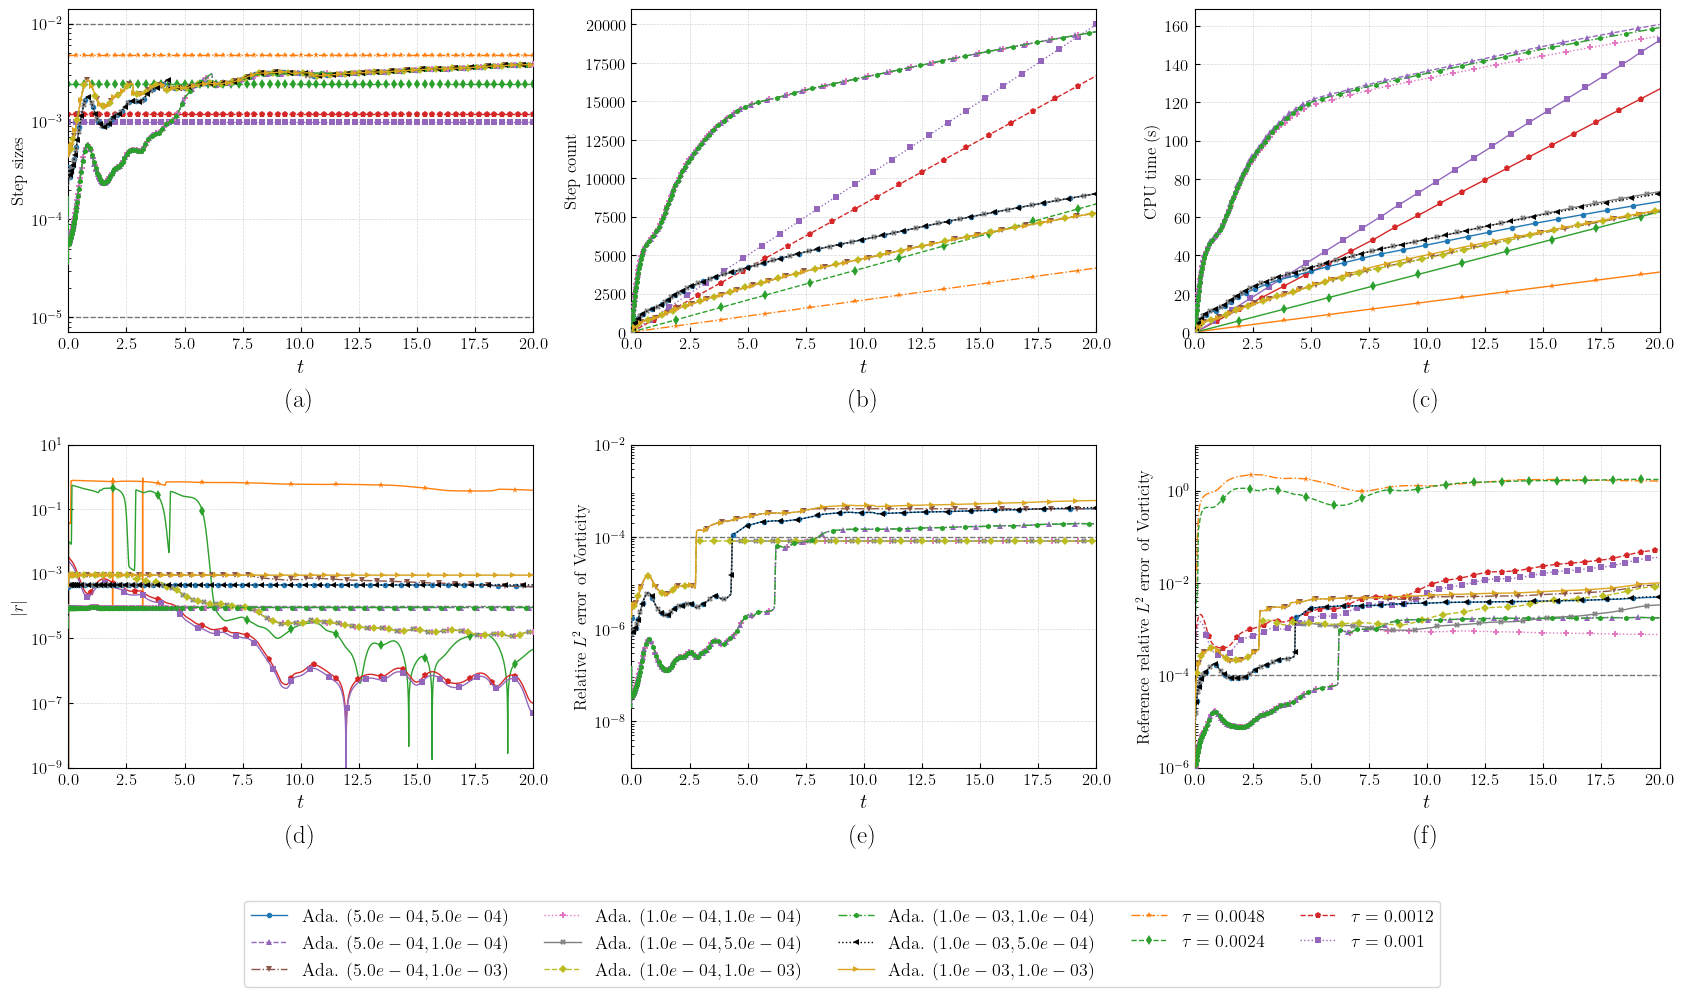

In [12]:
fig_tol_grid = plot_comparison(tol_grid_results, "fig/adaptive_step_tol_grid_0_20.png", legend_ncol=5)

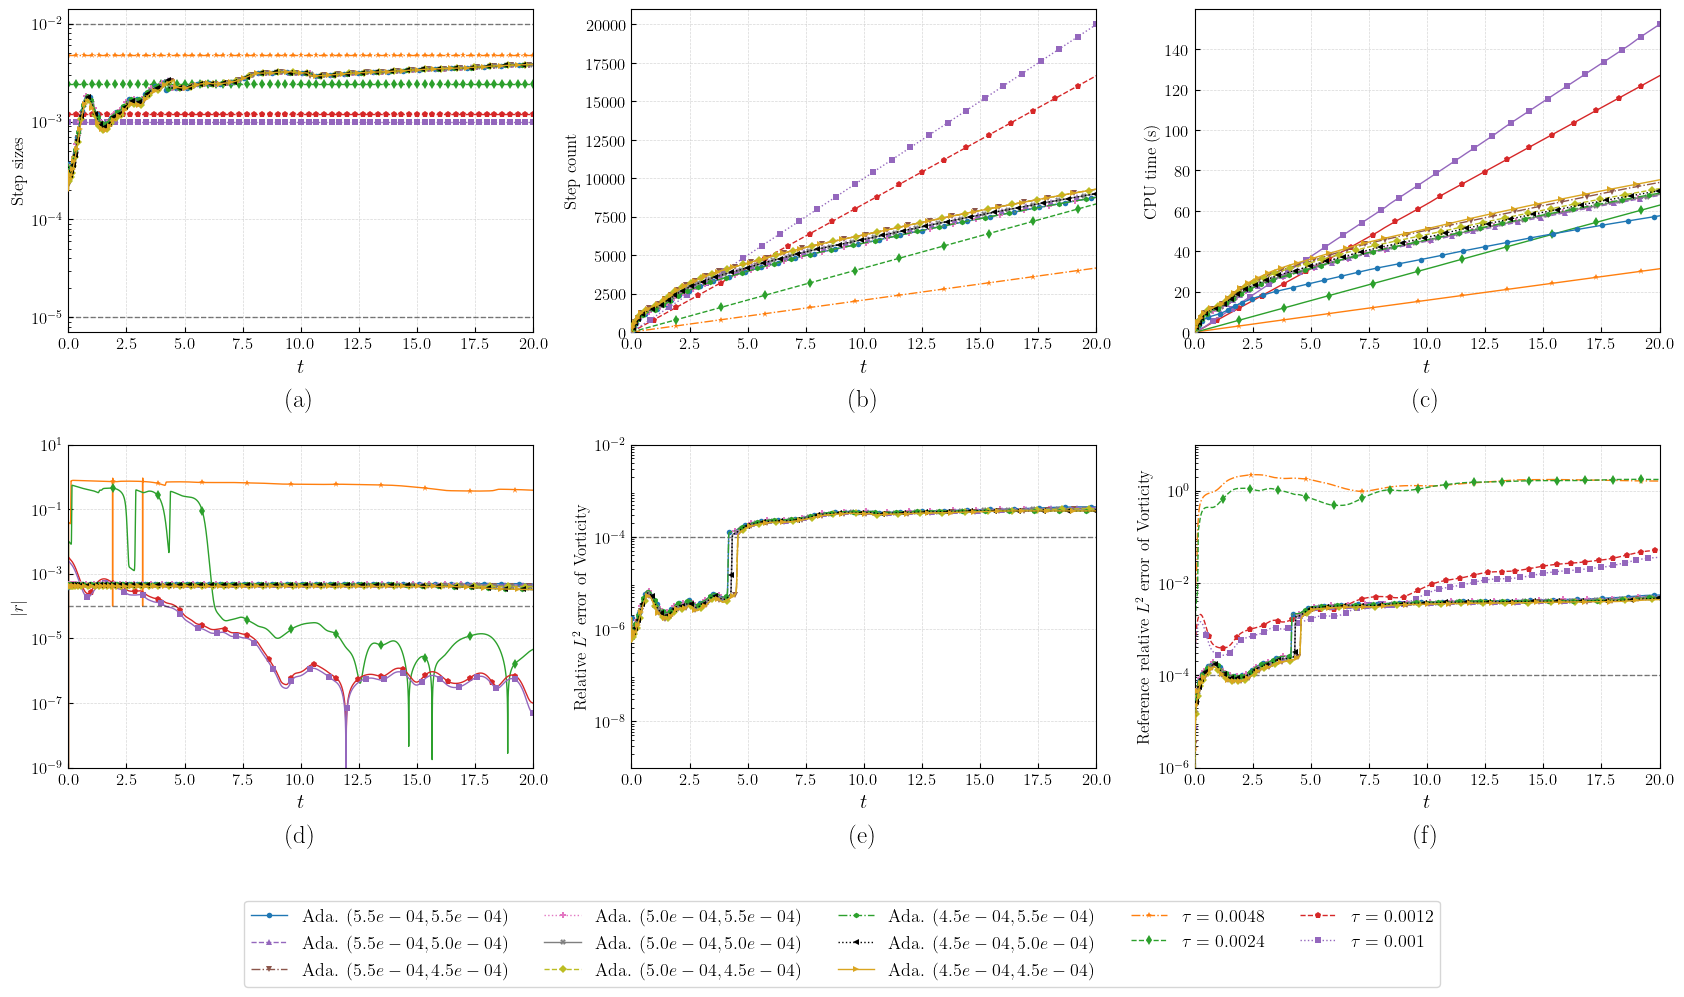

In [13]:
fig_tol_perturb = plot_comparison(tol_perturb_results, "fig/adaptive_step_tol_perturb_0_20.png", legend_ncol=5)

In [14]:
try:
    import pandas as pd
except ImportError:
    pd = None
from IPython.display import HTML, display

summary_t0 = 0.2
summary_rows = []


def window_mask(t, t0=summary_t0):
    return np.asarray(t) >= t0


def index_at_time(t, t0=summary_t0):
    return int(np.argmin(np.abs(np.asarray(t) - t0)))


def window_mean(t, y, t0=summary_t0):
    mask = window_mask(t, t0)
    return np.nanmean(np.asarray(y)[mask])


def interval_max(t, y, t0, t1):
    t = np.asarray(t)
    y = np.asarray(y)
    mask = (t >= t0) & (t <= t1)
    if not np.any(mask):
        return np.nan
    return np.nanmax(y[mask])


def final_increment_from_time(t, y, t0=summary_t0):
    y = np.asarray(y)
    return y[-1] - y[index_at_time(t, t0)]


summary_adaptive_results = list(tol_grid_results)
summary_adaptive_keys = {tol_key(res["rtol"], res["rtol_q"]) for res in summary_adaptive_results}
summary_adaptive_results.extend(
    res for res in tol_perturb_results
    if tol_key(res["rtol"], res["rtol_q"]) not in summary_adaptive_keys
)

for res in summary_adaptive_results:
    adaptive_step_count = np.arange(len(res["tn"]))
    adaptive_cpu_time = np.asarray(res["cpu_time"])
    summary_rows.append({
        "Method": "Adaptive",
        "Setting (tol_omega / tol_r)": rf"$({res['rtol']:.1e}, {res['rtol_q']:.1e})$",
        # "Time interval": rf"$[{summary_t0}, {t_period[1]}]$",
        "(a) Avg step size": window_mean(res["tn"], res["tau"]),
        "(b) Final step count": final_increment_from_time(res["tn"], adaptive_step_count),
        "(c) Final CPU time (s)": final_increment_from_time(res["tn"], adaptive_cpu_time),
        "(d) Avg |r| / |q-1|": window_mean(res["tn"], res["ref_err_p"]),
        "(e) Avg relative L2 error": window_mean(res["tn"], res["rel_err"]),
        "(f) Avg reference relative L2 error": window_mean(res["tn"], res["ref_err"]),
        "Max |r| [0,10]": interval_max(res["tn"], res["ref_err_p"], 0, 10),
        "Max |r| [10,20]": interval_max(res["tn"], res["ref_err_p"], 10, 20),
        "Max relative L2 error [0,10]": interval_max(res["tn"], res["rel_err"], 0, 10),
        "Max relative L2 error [10,20]": interval_max(res["tn"], res["rel_err"], 10, 20),
        "Max reference relative L2 error [0,10]": interval_max(res["tn"], res["ref_err"], 0, 10),
        "Max reference relative L2 error [10,20]": interval_max(res["tn"], res["ref_err"], 10, 20),
    })

for res in fixed_results:
    fixed_step_count = np.arange(len(res["tn"]))
    fixed_r_err = np.abs(res["q"] - 1)
    summary_rows.append({
        "Method": "Fixed",
        "Setting": rf"$\tau = {res['tau']:.3g}$",
        "Time interval": rf"$[{summary_t0}, {t_period[1]}]$",
        "(a) Avg step size": window_mean(res["tn"][:-1], res["tau_values"]),
        "(b) Final step count": len(res["tau_values"]),
        "(c) Final CPU time (s)": final_increment_from_time(res["tn"], res["cpu_time"]),
        "(d) Avg |r| / |q-1|": window_mean(res["tn"], fixed_r_err),
        "(e) Avg relative L2 error": np.nan,
        "(f) Avg reference relative L2 error": window_mean(res["tn"], res["ref_error"]),
        "Max |r| [0,10]": interval_max(res["tn"], fixed_r_err, 0, 10),
        "Max |r| [10,20]": interval_max(res["tn"], fixed_r_err, 10, 20),
        "Max relative L2 error [0,10]": np.nan,
        "Max relative L2 error [10,20]": np.nan,
        "Max reference relative L2 error [0,10]": interval_max(res["tn"], res["ref_error"], 0, 10),
        "Max reference relative L2 error [10,20]": interval_max(res["tn"], res["ref_error"], 10, 20),
    })

columns = [
    "Method",
    "Setting (tol_omega / tol_r)",
    "Setting",
    "Time interval",
    "(a) Avg step size",
    "(b) Final step count",
    "(c) Final CPU time (s)",
    "(d) Avg |r| / |q-1|",
    "Max |r| [0,10]",
    "Max |r| [10,20]",
    "(e) Avg relative L2 error",
    "Max relative L2 error [0,10]",
    "Max relative L2 error [10,20]",
    "(f) Avg reference relative L2 error",
    "Max reference relative L2 error [0,10]",
    "Max reference relative L2 error [10,20]",
]

if pd is not None:
    fig_summary_table = pd.DataFrame(summary_rows, columns=columns)
    formatters = {
        "(a) Avg step size": "{:.4e}".format,
        "(b) Final step count": "{:.0f}".format,
        "(c) Final CPU time (s)": "{:.3f}".format,
        "(d) Avg |r| / |q-1|": "{:.4e}".format,
        "(e) Avg relative L2 error": lambda x: "--" if pd.isna(x) else f"{x:.4e}",
        "(f) Avg reference relative L2 error": "{:.4e}".format,
        "Max |r| [0,10]": "{:.4e}".format,
        "Max |r| [10,20]": "{:.4e}".format,
        "Max relative L2 error [0,10]": lambda x: "--" if pd.isna(x) else f"{x:.4e}",
        "Max relative L2 error [10,20]": lambda x: "--" if pd.isna(x) else f"{x:.4e}",
        "Max reference relative L2 error [0,10]": "{:.4e}".format,
        "Max reference relative L2 error [10,20]": "{:.4e}".format,
    }
    display(fig_summary_table.style.format(formatters, na_rep="--"))
else:
    def format_summary_value(column, value):
        if isinstance(value, float) and np.isnan(value):
            return "--"
        if column == "(b) Final step count":
            return f"{value:.0f}"
        if column == "(c) Final CPU time (s)":
            return f"{value:.3f}"
        if isinstance(value, (float, np.floating)):
            return f"{value:.4e}"
        return str(value)

    header = "".join(f"<th>{column}</th>" for column in columns)
    body = "".join(
        "<tr>" + "".join(f"<td>{format_summary_value(column, row[column])}</td>" for column in columns) + "</tr>"
        for row in summary_rows
    )
    fig_summary_table = summary_rows
    display(HTML(f"<table><thead><tr>{header}</tr></thead><tbody>{body}</tbody></table>"))


AttributeError: The '.style' accessor requires jinja2